In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from affine import Affine

from tqdm.notebook import tqdm
import scipy
import dask.bag as db
from pyproj import Proj, Transformer, CRS
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape
import sklearn

import pandas as pd
plt.style.use('robin')
from matplotlib.colors import LogNorm, Normalize
proj = ccrs.NorthPolarStereo(0,70)

def sigmoid(x):
    return 1/(1+np.exp(-x))

In [2]:
cluster = LocalCluster(n_workers=4, memory_limit='12GiB')
client = Client(cluster)
client

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46121 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:46121/status,
Dashboard: http://127.0.0.1:46121/status,Workers: 4
Total threads: 64,Total memory: 48.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43589,Workers: 0
Dashboard: http://127.0.0.1:46121/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46219,Total threads: 16
Dashboard: http://127.0.0.1:34593/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:35191,


In [9]:
ds = xr.open_dataset('https://thredds.met.no/thredds/dodsC/senorge/seNorge_2018/Archive/seNorge2018_2024.nc')
mask=((ds.lon<7)*(ds.lat<62)).load()

In [15]:
for year in tqdm(range(1979, 2025)):
    ds_year = xr.open_dataset(f'https://thredds.met.no/thredds/dodsC/senorge/seNorge_2018/Archive/seNorge2018_{year}.nc')
    ds_year_region = ds_year.rr.where(mask).mean(dim=['X','Y'])
    ds_year_region.attrs['region'] = 'South Norway (lon<7, lat<62)'
    ds_year_region.to_netcdf(f'/home/rogui7909/data/senorge_regional_mean/senorge_regional_mean_{year}.nc')

  0%|          | 0/46 [00:00<?, ?it/s]

In [24]:
ds

<xarray.Dataset> Size: 202kB
Dimensions:  (time: 16802)
Coordinates:
  * time     (time) object 134kB 1979-01-01 1979-01-02 ... 2024-12-30 2024-12-31
Data variables:
    tp       (time) float32 67kB dask.array<chunksize=(365,), meta=np.ndarray>

In [37]:
ds_era=xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc')#.rename(tp='precipitation_amount')

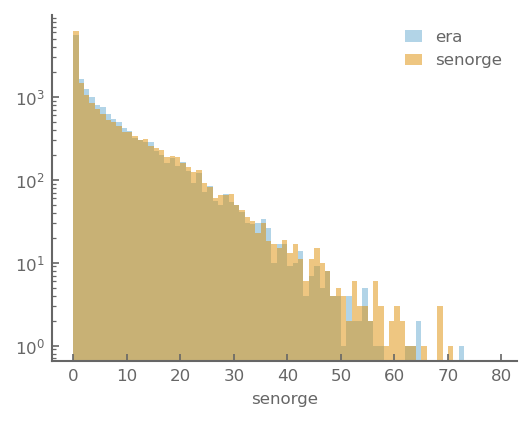

In [60]:
ds_ = xr.Dataset(dict(era=ds_era.tp, senorge=ds.tp)).load().dropna('time')

from xarrayutils import xr_linregress

xr_linregress(ds_.era, ds_.senorge)

ds_.era.plot.hist(label='era', bins=np.arange(0,80), alpha=.3)
ds_.senorge.plot.hist(label='senorge', bins=np.arange(0,80), alpha=.5)

plt.yscale('log')
plt.legend()

In [33]:
ds = xr.open_mfdataset('/home/rogui7909/data/senorge_regional_mean/senorge_regional_mean_*').rename(rr='tp')
ds.attrs['region'] = 'West Norway (lon<7, lat<62)'
ds['time'] = pd.to_datetime(ds.time.dt.strftime('%Y-%m-%d'))
ds.to_netcdf('/Data/gfi/users/rogui7909/data/precip/senorge_westnorway_1979-2014.nc')
ds

<xarray.Dataset> Size: 202kB
Dimensions:  (time: 16802)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
Data variables:
    tp       (time) float32 67kB dask.array<chunksize=(365,), meta=np.ndarray>
Attributes:
    region:   West Norway (lon<7, lat<62)

In [26]:
ds

<xarray.Dataset> Size: 202kB
Dimensions:  (time: 16802)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-01-01T06:00:00 ... 2024-12-31T0...
Data variables:
    tp       (time) float32 67kB dask.array<chunksize=(365,), meta=np.ndarray>

In [14]:
import os
os.makedirs('/home/rogui7909/data/senorge_regional_mean/')

In [10]:
da = ds.rr.sel(X=slice(None, .1e6), Y=slice(7e6, 6e6)).where(mask).mean(dim=['X','Y'])

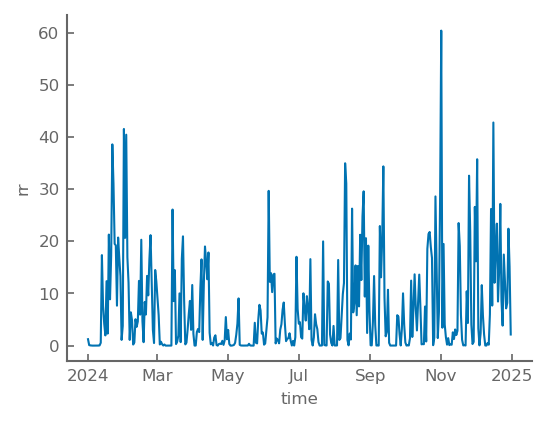

In [11]:
da.plot()

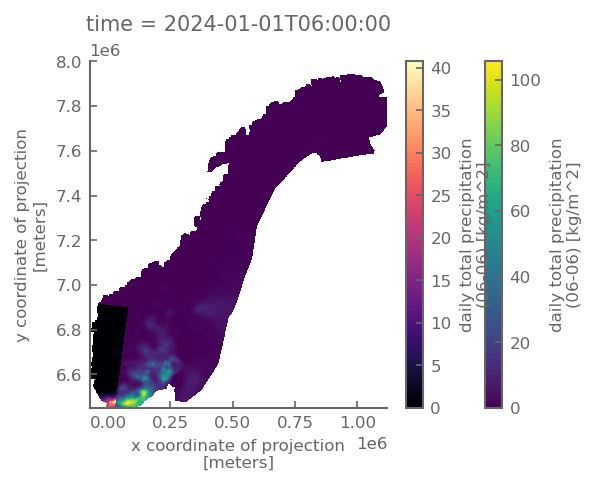

In [18]:
ds.rr.isel(time=0).plot()
ds.rr.isel(time=0).where(mask).plot(cmap='magma')

In [15]:
mask=(ds.lon<7)*(ds.lat<62)

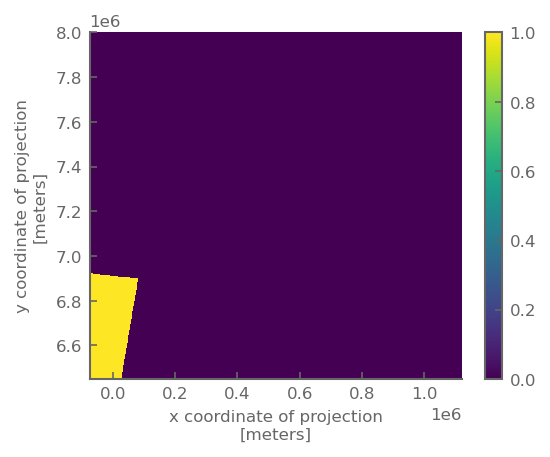

In [16]:
mask.plot()

(55.0, 65.0)

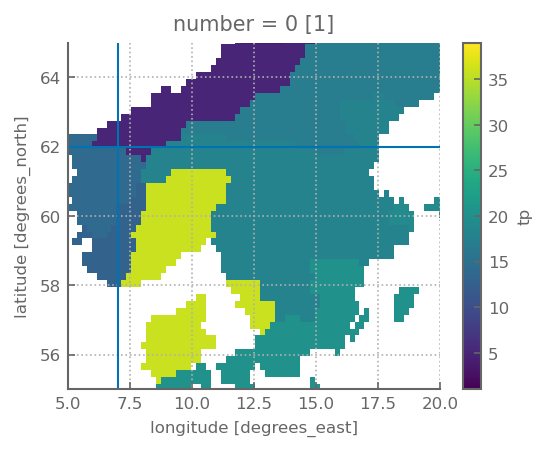

In [13]:
ds_regions = xr.open_dataset('/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/aux/ERA5_rainfall_regions.nc').tp
ds_regions.plot()
plt.grid()
plt.xlim(5,20)
plt.axvline(7)
plt.axhline(62)
plt.ylim(55,65)

In [ ]:
ds.rr.where(ds.lon<10).isel(time=0).plot(x='lon', y='lat')

Process Dask Worker process (from Nanny):
2026-01-12 15:11:46,498 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2026-01-12 15:11:46,498 - distributed.nanny - ERROR - Worker process died unexpectedly
2026-01-12 15:11:46,498 - distributed.nanny - ERROR - Worker process died unexpectedly
2026-01-12 15:11:46,498 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2026-01-12 15:11:46,499 - distributed.nanny - ERROR - Worker process died unexpectedly
2026-01-12 15:11:46,501 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2026-01-12 15:11:46,504 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most rece